# Creating a single-arm variant of the bimanual model

The `bimanual` model has two muscle-actuated arms. For some workflows, a single arm is preferable,
such as a single-arm manipulation task or a policy with a smaller action space. This notebook shows
two ways to handle the unused arm:

| Helper | Result | Bodies / bones | Action space (`nu`) |
|--------|--------|----------------|---------------------|
| **`remove_arm(keep)`** | the unused arm is removed from the compiled model | removed | 126 to 63 |
| **`freeze_arm(keep)`** | the unused arm remains visible but is welded in place | kept, rigid | 126 to 63 |

Both helpers rebuild the model with [`MjSpec`](https://mujoco.readthedocs.io/en/stable/python.html#model-editing)
(available in the project's MuJoCo requirement) so the kept arm is the only side with active muscles.
A lightweight action-masking variant that avoids recompilation is shown at the end.


In [1]:
import os
os.environ.setdefault("MUJOCO_GL", "egl")   # off-screen rendering; remove if you have a display

import numpy as np
import matplotlib.pyplot as plt
import mujoco
import musclemimic_models as mm

model, data = mm.load("bimanual")
print("full bimanual:  nu =", model.nu, " ntendon =", model.ntendon,
      " njnt =", model.njnt, " nbody =", model.nbody)

full bimanual:  nu = 126  ntendon = 134  njnt = 76  nbody = 77


## Naming convention

The two sides are distinguished by name suffixes:

|                       | Right arm                          | Left arm                                  |
|-----------------------|------------------------------------|-------------------------------------------|
| **Muscle actuators**  | no suffix, e.g. `BIClong`, `DELT1` | `_left`, e.g. `BIClong_left`, `DELT1_left` |
| **Tendons**           | `*_tendon` plus ligaments          | `*_tendon_left` plus `*_left` ligaments   |
| **Bodies / joints**   | `*_r`, e.g. `humerus_r`, `elbow_flex_r` | `*_l`, e.g. `humerus_l`, `elbow_flex_l` |

An actuator or tendon is on the left side when its name ends with `_left`; a body or joint is on the
left side when its name ends with `_l`. Therefore, `keep="right"` removes the `_left` / `_l` elements,
and `keep="left"` removes the corresponding right-side elements.


In [2]:
def names(model, obj, n):
    return [mujoco.mj_id2name(model, obj, i) for i in range(n)]

act = names(model, mujoco.mjtObj.mjOBJ_ACTUATOR, model.nu)
print(f"actuators: {sum(not n.endswith('_left') for n in act)} right + "
      f"{sum(n.endswith('_left') for n in act)} left = {len(act)}")
print("right elbow flexors:", [n for n in act if n in {'BIClong', 'BICshort', 'BRA'}])
print("left  elbow flexors:", [n for n in act if n in {'BIClong_left', 'BICshort_left', 'BRA_left'}])

actuators: 63 right + 63 left = 126
right elbow flexors: ['BIClong', 'BICshort', 'BRA']
left  elbow flexors: ['BIClong_left', 'BICshort_left', 'BRA_left']


A small set of rendering helpers is reused below. They match the helpers in the first notebook.


In [3]:
def frame_camera(model, data, azimuth=-90.0, elevation=-10.0, pad=1.4):
    """Free camera framed tightly on the model's bodies (ignores the floor)."""
    mujoco.mj_forward(model, data)
    geom_ids = [i for i in range(model.ngeom)
                if mujoco.mj_id2name(model, mujoco.mjtObj.mjOBJ_GEOM, i) != "floor"]
    pts = data.geom_xpos[geom_ids]
    lo, hi = pts.min(0), pts.max(0)
    cam = mujoco.MjvCamera()
    cam.type = mujoco.mjtCamera.mjCAMERA_FREE
    cam.lookat[:] = 0.5 * (lo + hi)
    cam.distance = pad * float(np.linalg.norm(hi - lo))
    cam.azimuth, cam.elevation = azimuth, elevation
    return cam


def make_renderer(model, width, height):
    model.vis.global_.offwidth = max(int(model.vis.global_.offwidth), width)
    model.vis.global_.offheight = max(int(model.vis.global_.offheight), height)
    return mujoco.Renderer(model, height, width)


def curl_rollout(model, flexors, seconds=2.5, fps=30, cam_azimuth=-90, pad=1.25):
    """Drive `flexors` with a sine-shaped control input; return rendered frames."""
    data = mujoco.MjData(model)
    cam = frame_camera(model, data, azimuth=cam_azimuth, pad=pad)
    fids = [mujoco.mj_name2id(model, mujoco.mjtObj.mjOBJ_ACTUATOR, n) for n in flexors]
    missing = [name for name, idx in zip(flexors, fids) if idx < 0]
    if missing:
        raise ValueError(f"Missing actuators: {missing}")
    frames = []
    with make_renderer(model, 480, 360) as r:
        while data.time < seconds:
            a = 0.5 * (1 - np.cos(2 * np.pi * 0.5 * data.time))
            data.ctrl[:] = 0.0
            data.ctrl[fids] = a
            mujoco.mj_step(model, data)
            if len(frames) < data.time * fps:
                r.update_scene(data, camera=cam)
                frames.append(r.render())
    return frames


def show_strip(frames, title, n=5):
    idx = np.linspace(0, len(frames) - 1, n).astype(int)
    fig, axes = plt.subplots(1, len(idx), figsize=(3 * len(idx), 3.2))
    for ax, i in zip(axes, idx):
        ax.imshow(frames[i])
        ax.axis("off")
    fig.suptitle(title)
    plt.tight_layout()
    plt.show()

## Option A: remove the other arm entirely (`remove_arm`)

First, delete the unused arm's actuators and tendons. Then delete its root body (`clavicle_l` or
`clavicle_r`), which removes the full subtree: child bodies, bone geoms, joints, and sites. Finally,
prune any remaining elements that referenced the deleted names, including joint-coupling equalities,
per-body velocity sensors, and contact excludes or pairs.

This cleanup is required; otherwise `compile()` fails with unresolved-reference errors.


In [4]:
def remove_arm(keep="right", xml_path=None):
    """Compile a bimanual model with the unused arm removed entirely.

    Deletes that arm's actuators, tendons, and full body subtree, then prunes
    equalities, sensors, and contacts that referenced the deleted parts.
    """
    assert keep in ("right", "left")
    drop_left = (keep == "right")
    spec = mujoco.MjSpec.from_file(xml_path or str(mm.get_xml_path("bimanual")))

    # 1. Muscles (actuators) and tendons of the removed side ('_left' == left arm).
    for a in list(spec.actuators):
        if a.name.endswith("_left") == drop_left:
            spec.delete(a)
    for t in list(spec.tendons):
        if t.name.endswith("_left") == drop_left:
            spec.delete(t)

    # 2. The arm's root body; deleting it removes the subtree (bodies, joints, sites).
    spec.delete(spec.body("clavicle_l" if drop_left else "clavicle_r"))

    # 3. Prune anything that still points at a deleted name.
    bodies = {b.name for b in spec.bodies}
    geoms  = {g.name for g in spec.geoms if g.name}
    joints = {j.name for j in spec.joints}
    sites  = {s.name for s in spec.sites if s.name}
    for e in list(spec.equalities):                       # joint couplers
        if e.name1 not in joints or (e.name2 and e.name2 not in joints):
            spec.delete(e)
    for s in list(spec.sensors):                          # per-body velocity sensors
        if s.objname and s.objname not in (bodies | geoms | joints | sites):
            spec.delete(s)
    for ex in list(spec.excludes):                        # contact-exclude pairs
        if ex.bodyname1 not in bodies or ex.bodyname2 not in bodies:
            spec.delete(ex)
    for p in list(spec.pairs):                            # explicit contact pairs
        if p.geomname1 not in geoms or p.geomname2 not in geoms:
            spec.delete(p)
    return spec.compile()


right_only = remove_arm("right")
left_only  = remove_arm("left")
for tag, m in [("full", mm.load("bimanual")[0]), ("right_only", right_only), ("left_only", left_only)]:
    print(f"{tag:11s}: nbody={m.nbody:3d}  nu={m.nu:3d}  njnt={m.njnt:3d}  "
          f"ntendon={m.ntendon:3d}  neq={m.neq:3d}  nsensor={m.nsensor:3d}")

full       : nbody= 77  nu=126  njnt= 76  ntendon=134  neq= 22  nsensor=106
right_only : nbody= 41  nu= 63  njnt= 38  ntendon= 67  neq= 11  nsensor= 56
left_only  : nbody= 41  nu= 63  njnt= 38  ntendon= 67  neq= 11  nsensor= 56


The unused arm is absent from the compiled model. Drive the remaining arm to confirm that it still
works:


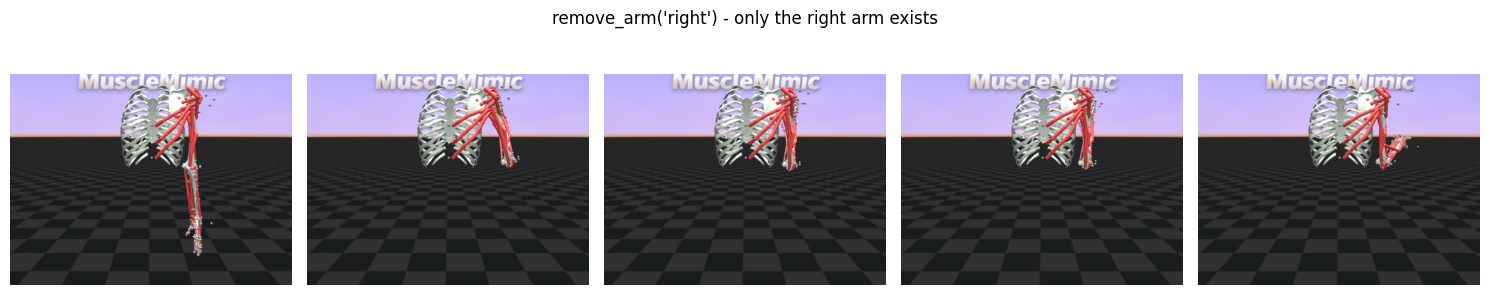

In [5]:
frames = curl_rollout(right_only, ["BIClong", "BICshort", "BRA", "BRD"])
show_strip(frames, "remove_arm('right') - only the right arm exists")

## Option B: freeze the other arm in place (`freeze_arm`)

If the unused arm should remain visible but static, delete its joints instead of its bodies. A body
with no joint is rigidly welded to its parent; because this model is fixed-base, removing all joints
on one arm welds that arm to the static torso.

Two additional cleanup steps are needed: remove joint-coupling equalities that referenced the deleted
joints, and remove any contact pair that would sit between two static bodies. MuJoCo rejects such
static-vs-static contact pairs during compilation. The unused side's actuators and tendons are still
removed, so the frozen side has no muscles.


In [6]:
def freeze_arm(keep="right", xml_path=None):
    """Compile a bimanual model where the unused arm is visible but welded in place.

    Deletes that arm's joints, actuators, and tendons, then removes joint
    couplers and contact pairs that would reference invalid or static-only elements.
    """
    assert keep in ("right", "left")
    drop_left = (keep == "right")
    bsuf = "_l" if drop_left else "_r"

    def on_drop(n):  return bool(n) and (n.endswith(bsuf) or (bsuf + "_") in n)
    def on_arm(n):   return bool(n) and (n.endswith("_l") or n.endswith("_r")
                                         or "_l_" in n or "_r_" in n)
    def is_static(n):                       # frozen-side geom, or a base geom (torso/root)
        return on_drop(n) or (n != "floor" and not on_arm(n))

    spec = mujoco.MjSpec.from_file(xml_path or str(mm.get_xml_path("bimanual")))
    for a in list(spec.actuators):
        if a.name.endswith("_left") == drop_left:
            spec.delete(a)
    for t in list(spec.tendons):
        if t.name.endswith("_left") == drop_left:
            spec.delete(t)
    for j in list(spec.joints):             # remove degrees of freedom; bodies weld rigid
        if j.name.endswith(bsuf):
            spec.delete(j)

    joints = {j.name for j in spec.joints}
    for e in list(spec.equalities):         # couplers that referenced the removed joints
        if e.name1 not in joints or (e.name2 and e.name2 not in joints):
            spec.delete(e)
    for p in list(spec.pairs):              # avoid static-vs-static contacts
        if is_static(p.geomname1) and is_static(p.geomname2):
            spec.delete(p)
    return spec.compile()


right_active = freeze_arm("right")
print(f"freeze_arm('right'): nbody={right_active.nbody}  nu={right_active.nu}  "
      f"njnt={right_active.njnt}  (both arms still present, only the right has joints)")

freeze_arm('right'): nbody=77  nu=63  njnt=38  (both arms still present, only the right has joints)


Check that the frozen left arm does not move when the right arm is driven:


frozen left-arm bodies, max displacement after 400 steps: 0.00e+00 m


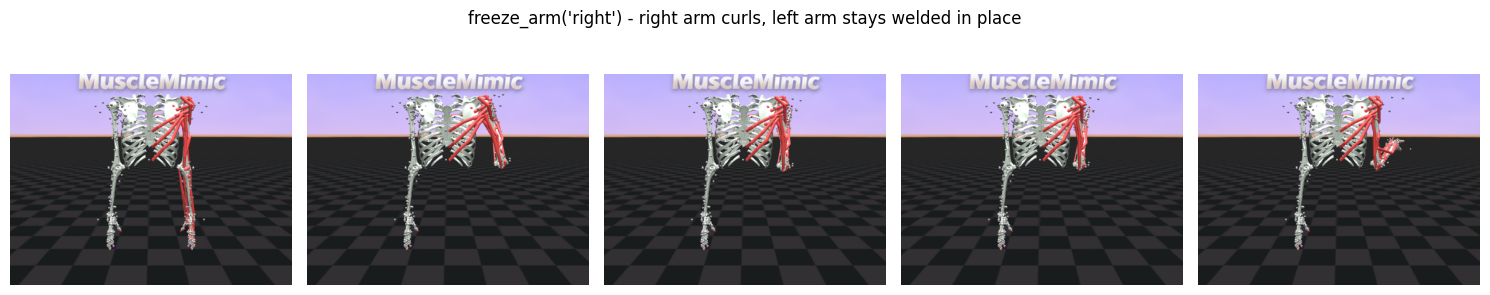

In [7]:
m = right_active
d = mujoco.MjData(m)
left_bodies = [i for i in range(m.nbody)
               if (mujoco.mj_id2name(m, mujoco.mjtObj.mjOBJ_BODY, i) or "").endswith("_l")]
mujoco.mj_forward(m, d)
p0 = d.xpos[left_bodies].copy()

for _ in range(400):
    d.ctrl[:] = 0.6                 # moderately high input on every right-arm muscle
    mujoco.mj_step(m, d)

print("frozen left-arm bodies, max displacement after 400 steps:",
      f"{float(np.abs(d.xpos[left_bodies] - p0).max()):.2e} m")

frames = curl_rollout(right_active, ["BIClong", "BICshort", "BRA", "BRD"], pad=1.35)
show_strip(frames, "freeze_arm('right') - right arm curls, left arm stays welded in place")

## Action masking without recompilation

If model dimensions must stay fixed, such as when using a fixed-size reinforcement-learning action
vector, one side's muscles can be neutralized on the live `MjModel`. The muscles are Hill-type: their
peak force `F0` is stored in `actuator_gainprm[:, 2]` for active force and `actuator_biasprm[:, 2]`
for passive force. Zero both values so the muscle produces no force at any control input; also zero
that side's `tendon_stiffness` so passive tendon springs do not apply force.

> Note: this only removes muscle drive. The arm's joints still exist, so that arm remains unactuated
> and can move under gravity. If it needs to be removed or held fixed, use `remove_arm` or `freeze_arm`.


In [8]:
def disable_side_inplace(model, side="left"):
    """Neutralize one arm on a live MjModel. Returns (disabled, kept) actuator ids."""
    assert side in ("left", "right")
    want_left = (side == "left")
    def side_ids(obj, n):
        out = []
        for i in range(n):
            nm = mujoco.mj_id2name(model, obj, i)
            if nm is not None and nm.endswith("_left") == want_left:
                out.append(i)
        return out

    dis_act = side_ids(mujoco.mjtObj.mjOBJ_ACTUATOR, model.nu)
    dis_ten = side_ids(mujoco.mjtObj.mjOBJ_TENDON, model.ntendon)
    model.actuator_gainprm[dis_act, 2] = 0.0   # no active muscle force
    model.actuator_biasprm[dis_act, 2] = 0.0   # no passive muscle force
    model.tendon_stiffness[dis_ten] = 0.0      # no passive tendon spring
    disabled_set = set(dis_act)
    kept = [i for i in range(model.nu) if i not in disabled_set]
    return dis_act, kept


model, _ = mm.load("bimanual")
disabled, kept = disable_side_inplace(model, side="left")
print(f"disabled {len(disabled)} left actuators; {len(kept)} remain controllable; nu unchanged = {model.nu}")

probe = mujoco.MjData(model)
probe.act[disabled] = 1.0
mujoco.mj_forward(model, probe)
print("max |force| on disabled side at unit activation state:",
      float(np.abs(probe.actuator_force[disabled]).max()))

disabled 63 left actuators; 63 remain controllable; nu unchanged = 126
max |force| on disabled side at unit activation state: 0.0


## Summary

- Right-side elements have no suffix; left-side elements end in `_left` for actuators/tendons or `_l`
  for bodies/joints.
- `remove_arm(keep)` removes the unused arm, including its bodies and geoms. In the current model,
  `nbody` changes from 77 to 41 and `nu` changes from 126 to 63.
- `freeze_arm(keep)` keeps the unused arm visible but welds it in place. In the current model, `nu`
  changes from 126 to 63 and `njnt` changes from 76 to 38.
- `disable_side_inplace` does not recompile and leaves model dimensions unchanged, but the unused arm
  remains unactuated rather than removed or fixed.
